In [47]:
%pip install -q imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

print("Libraries imported successfully!")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


In [48]:
# Load preprocessed dataset from local data directory
import os
file_path = "/home/chandima-bandara/Desktop/student-retention-analysis/data/preprocessed_university_student_retention.csv"


In [49]:
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2134, 22)


,student_id,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,...,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,dropout_risk,next_semester_dropout,dropout_type,dropout_duration,dropout_cause
0,S1000,21,Other,Black,Psychology,3.17,2.77,0.88,0,42,...,2,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.44, 2.24, 3.12, 2.32]","[0.82, 0.8, 0.78, 0.69]",False,False,No Dropout,0,No Dropout
1,S1001,26,Male,Hispanic,Business,2.99,2.72,0.72,3,109,...,5,Student discussed academic goals and current c...,No Counseling Record,"[3.11, 3.4, 2.75, 2.86]","[0.98, 0.92, 0.96, 0.91]",False,False,No Dropout,0,No Dropout
2,S1002,26,Other,Black,Psychology,2.45,2.25,0.79,1,119,...,5,Student discussed academic goals and current c...,No Counseling Record,"[3.37, 3.29, 2.8, 3.56]","[0.72, 0.95, 0.54, 0.98]",False,False,No Dropout,0,No Dropout
3,S1003,21,Other,Asian,Psychology,3.82,3.79,0.97,3,38,...,4,Student discussed academic goals and current c...,No Counseling Record,"[3.04, 2.81, 3.18, 3.82]","[0.77, 0.79, 0.54, 0.86]",False,False,No Dropout,0,No Dropout
4,S1004,19,Male,Hispanic,Electrical Engineering,2.18,1.97,0.56,0,26,...,1,Student discussed academic goals and current c...,No Counseling Record,"[3.5, 1.96, 2.24, 3.48]","[0.59, 0.96, 0.71, 0.54]",True,True,Permanent,0,Financial


In [50]:
# Filter key columns and randomly sample 30 rows
key_cols = [
    "gpa_current",
    "gpa_history",
    "attendance_rate",
    "credits_completed",
    "financial_aid_status",
    "academic_warning_count",
    "next_semester_dropout"
]

df_sample = df[key_cols].sample(n=30, random_state=42).reset_index(drop=True)

print("Random 30-row sample — Key Features vs Target:")
display(df_sample)

Random 30-row sample — Key Features vs Target:


,gpa_current,gpa_history,attendance_rate,credits_completed,financial_aid_status,academic_warning_count,next_semester_dropout
0,2.50,2.03,0.70,99,False,3,False
1,3.31,3.25,0.56,43,True,0,False
2,2.61,2.50,0.65,108,True,3,False
3,2.76,2.50,0.62,29,False,1,False
4,2.66,2.37,0.85,84,True,2,False
5,2.52,2.14,0.57,59,False,1,False
6,2.83,2.69,0.77,85,False,3,False
7,2.32,2.28,0.99,101,False,0,False
8,1.55,1.31,0.84,86,False,1,False
9,2.06,1.63,0.91,31,True,2,False


In [51]:
target_columns = [
    "dropout_risk",
    "next_semester_dropout"
]

for col in target_columns:
    print("\nTarget:", col)
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True) * 100)


Target: dropout_risk
dropout_risk
False    1536
True      598
Name: count, dtype: int64
dropout_risk
False    71.977507
True     28.022493
Name: proportion, dtype: float64

Target: next_semester_dropout
next_semester_dropout
False    1773
True      361
Name: count, dtype: int64
next_semester_dropout
False    83.083411
True     16.916589
Name: proportion, dtype: float64


In [52]:
df_corr = df.copy()

df_corr["next_semester_dropout"] = (
    df_corr["next_semester_dropout"].astype(int)
)

numeric_columns = df_corr.select_dtypes(
    include=["int64", "float64"]
).columns

correlations = (
    df_corr[numeric_columns]
    .corr()["next_semester_dropout"]
    .sort_values(ascending=False)
)

print(correlations)

next_semester_dropout     1.000000
dropout_duration          0.548074
academic_warning_count    0.027239
attendance_rate           0.019529
advisor_meeting_count     0.018714
gpa_current               0.004051
gpa_history              -0.005296
age                      -0.007967
credits_completed        -0.031907
enrollment_gap_months    -0.032283
Name: next_semester_dropout, dtype: float64


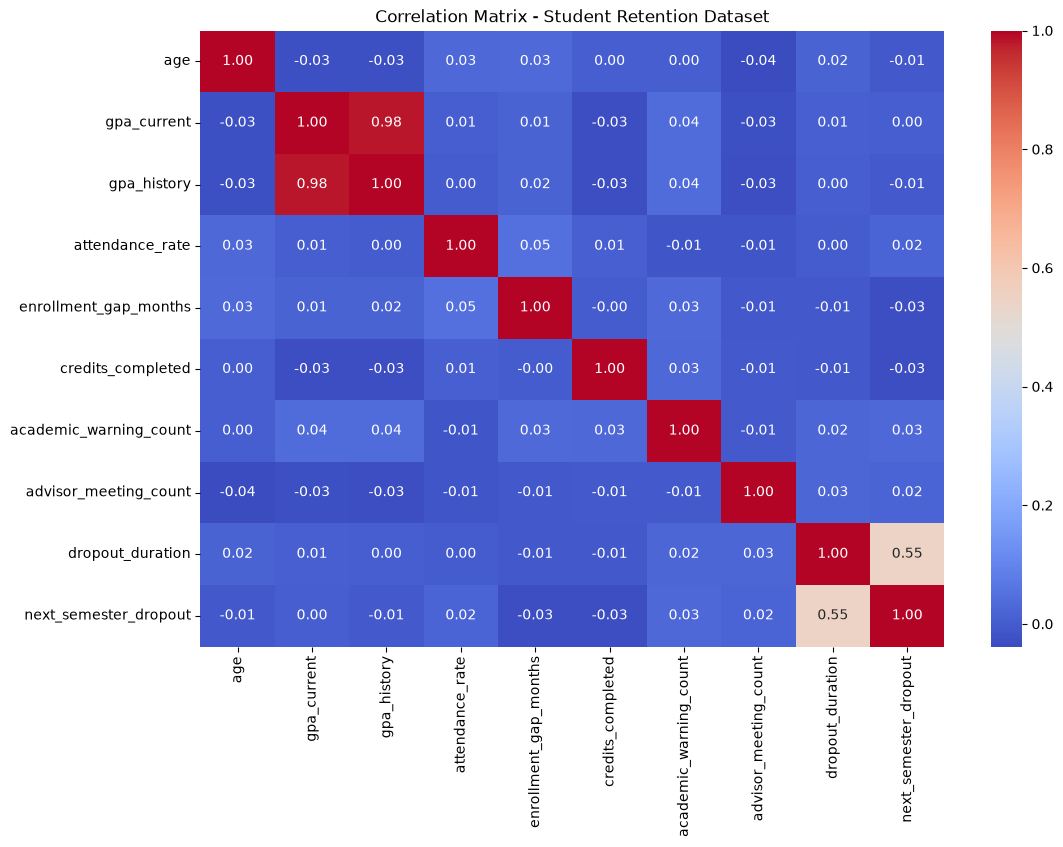

In [53]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
).copy()

numeric_df["next_semester_dropout"] = (
    df["next_semester_dropout"].astype(int)
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Student Retention Dataset")
plt.show()

In [54]:
TARGET = "next_semester_dropout"

y = df[TARGET].astype(int)

print(y.value_counts())

next_semester_dropout
0    1773
1     361
Name: count, dtype: int64


In [55]:
drop_columns = [
    "student_id",
    "next_semester_dropout",
    "dropout_type",
    "dropout_duration",
    "dropout_cause",
    "dropout_risk"
]

In [56]:
X = df.drop(columns=drop_columns)

print("Features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

Features:
['age', 'gender', 'ethnicity', 'major', 'gpa_current', 'gpa_history', 'attendance_rate', 'enrollment_gap_months', 'credits_completed', 'financial_aid_status', 'academic_warning_count', 'advisor_meeting_count', 'advising_notes', 'counseling_notes', 'gpa_by_semester', 'attendance_by_semester']

Number of features: 16


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (1707, 16)
Testing set: (427, 16)

Training target:
next_semester_dropout
0    1418
1     289
Name: count, dtype: int64

Testing target:
next_semester_dropout
0    355
1     72
Name: count, dtype: int64


In [58]:
%pip install -q imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [59]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

print("Before oversampling:")
print(y_train.value_counts())

print("\nAfter oversampling:")
print(y_train_balanced.value_counts())

Before oversampling:
next_semester_dropout
0    1418
1     289
Name: count, dtype: int64

After oversampling:
next_semester_dropout
0    1418
1    1418
Name: count, dtype: int64


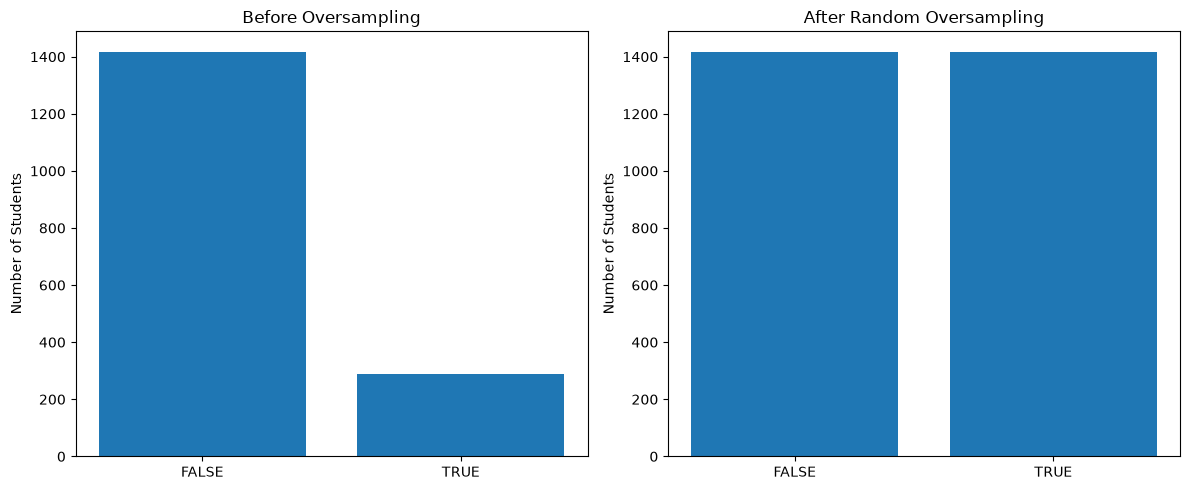

In [60]:
before = y_train.value_counts()
after = y_train_balanced.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    ["FALSE", "TRUE"],
    [before.get(0, 0), before.get(1, 0)]
)

axes[0].set_title("Before Oversampling")
axes[0].set_ylabel("Number of Students")

axes[1].bar(
    ["FALSE", "TRUE"],
    [after.get(0, 0), after.get(1, 0)]
)

axes[1].set_title("After Random Oversampling")
axes[1].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [61]:
balanced_df = X_train_balanced.copy()

balanced_df[TARGET] = y_train_balanced

print("Balanced dataset shape:")
print(balanced_df.shape)

print("\nTarget distribution:")
print(balanced_df[TARGET].value_counts())

Balanced dataset shape:
(2836, 17)

Target distribution:
next_semester_dropout
0    1418
1    1418
Name: count, dtype: int64


In [62]:
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(balanced_df.head())

   age  gender ethnicity                   major  gpa_current  gpa_history  \
0   25    Male     Black                 Biology         3.95         3.57   
1   24   Other     Asian                 Biology         2.20         2.09   
2   19   Other     Other                Business         1.81         1.62   
3   25   Other     Black        Computer Science         3.83         3.69   
4   26  Female     Other  Electrical Engineering         3.27         2.82   

   attendance_rate  enrollment_gap_months  credits_completed  \
0             0.76                      3                 20   
1             0.96                      3                 22   
2             0.51                      0                 89   
3             0.71                      0                109   
4             0.57                      0                 21   

   financial_aid_status  academic_warning_count  advisor_meeting_count  \
0                 False                       2                      3  

In [63]:
output_file = "/home/chandima-bandara/Desktop/student-retention-analysis/data/student_retention_balanced_dataset.csv"

balanced_df.to_csv(
    output_file,
    index=False
)

print("Balanced dataset successfully extracted and saved to:", output_file)


Balanced dataset successfully extracted and saved to: /home/chandima-bandara/Desktop/student-retention-analysis/data/student_retention_balanced_dataset.csv


In [64]:
print("========== FINAL CHECK ==========")

print("\nDataset shape:")
print(balanced_df.shape)

print("\nTarget column:")
print(TARGET)

print("\nTarget values:")
print(balanced_df[TARGET].value_counts())

print("\nTarget percentages:")
print(
    balanced_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMissing values:")
print(balanced_df.isnull().sum())

========== FINAL CHECK ==========

Dataset shape:
(2836, 17)

Target column:
next_semester_dropout

Target values:
next_semester_dropout
1    1418
0    1418
Name: count, dtype: int64

Target percentages:
next_semester_dropout
1    50.0
0    50.0
Name: proportion, dtype: float64

Missing values:
age                       0
gender                    0
ethnicity                 0
major                     0
gpa_current               0
gpa_history               0
attendance_rate           0
enrollment_gap_months     0
credits_completed         0
financial_aid_status      0
academic_warning_count    0
advisor_meeting_count     0
advising_notes            0
counseling_notes          0
gpa_by_semester           0
attendance_by_semester    0
next_semester_dropout     0
dtype: int64


========== CORRELATION WITH TARGET (BALANCED DATASET) ==========
next_semester_dropout     1.000000
attendance_rate           0.062953
advisor_meeting_count     0.059417
gpa_current               0.033058
gpa_history               0.022688
academic_warning_count    0.010075
age                      -0.011330
credits_completed        -0.063698
enrollment_gap_months    -0.098338
Name: next_semester_dropout, dtype: float64


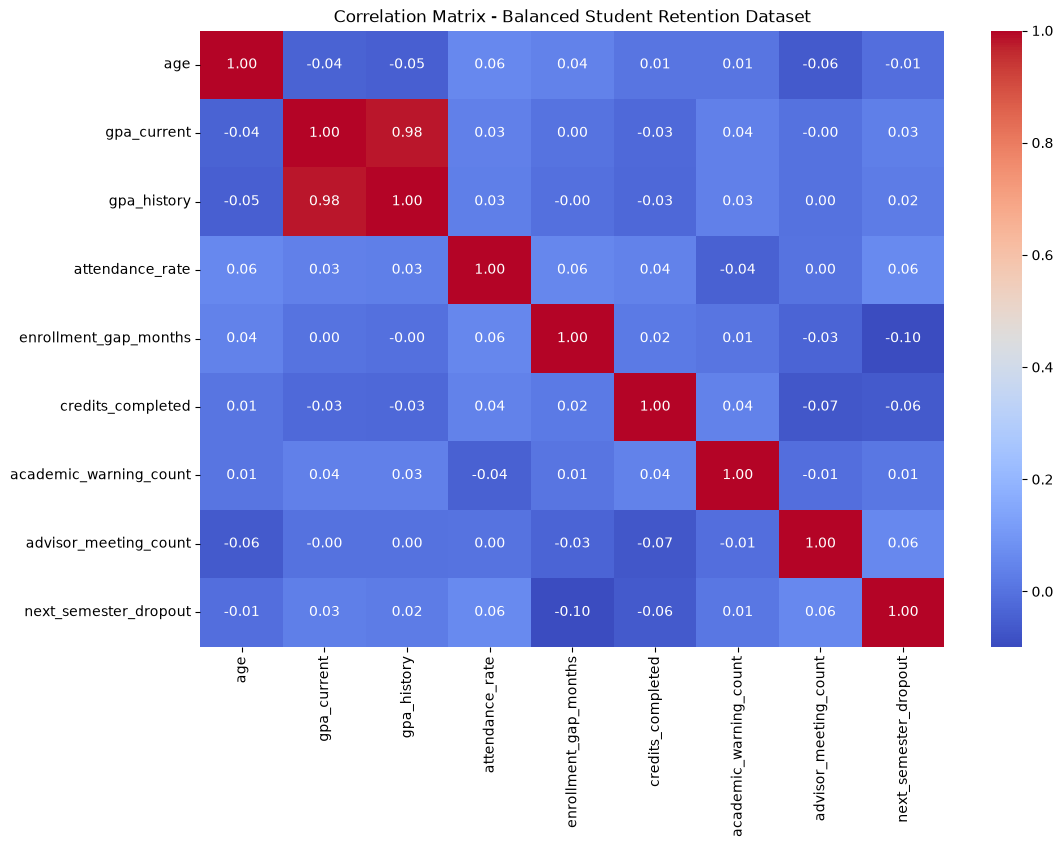

In [65]:
df_corr_balanced = balanced_df.copy()
df_corr_balanced[TARGET] = df_corr_balanced[TARGET].astype(int)
numeric_cols_balanced = df_corr_balanced.select_dtypes(include=["int64", "float64", "int32"]).columns
correlations_balanced = df_corr_balanced[numeric_cols_balanced].corr()[TARGET].sort_values(ascending=False)

print("========== CORRELATION WITH TARGET (BALANCED DATASET) ==========")
print(correlations_balanced)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr_balanced[numeric_cols_balanced].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Balanced Student Retention Dataset")
plt.show()


In [66]:
print("========== FIRST 5 ROWS ==========")
display(balanced_df.head(5))

print("\n========== LAST 5 ROWS ==========")
display(balanced_df.tail(5))

========== FIRST 5 ROWS ==========


,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,next_semester_dropout
0,25,Male,Black,Biology,3.95,3.57,0.76,3,20,False,2,3,Student discussed academic goals and current c...,No Counseling Record,"[2.76, 3.62, 1.55, 3.01]","[0.64, 0.93, 0.64, 0.84]",1
1,24,Other,Asian,Biology,2.20,2.09,0.96,3,22,True,2,2,Student discussed academic goals and current c...,No Counseling Record,"[4.0, 1.99, 3.03, 2.55]","[0.94, 0.88, 0.8, 0.51]",0
2,19,Other,Other,Business,1.81,1.62,0.51,0,89,True,3,0,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[3.29, 2.57, 2.27, 3.91]","[0.98, 0.64, 0.74, 0.99]",0
3,25,Other,Black,Computer Science,3.83,3.69,0.71,0,109,True,1,3,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.53, 2.56, 3.26, 3.86]","[0.63, 0.72, 0.9, 0.8]",1
4,26,Female,Other,Electrical Engineering,3.27,2.82,0.57,0,21,True,1,0,Student discussed academic goals and current c...,No Counseling Record,"[3.14, 3.32, 3.47, 2.11]","[0.65, 0.74, 0.53, 0.81]",1



========== LAST 5 ROWS ==========


,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,next_semester_dropout
2831,19,Female,White,Business,2.39,2.28,0.88,0,106,False,3,0,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.3, 2.98, 1.68, 1.87]","[0.54, 0.91, 0.88, 0.88]",0
2832,25,Male,Asian,Computer Science,2.67,2.35,0.72,0,73,True,1,3,Student discussed academic goals and current c...,No Counseling Record,"[1.78, 2.65, 3.15, 2.39]","[0.6, 0.91, 0.68, 0.6]",0
2833,27,Other,Black,Business,3.45,2.99,0.98,3,28,True,0,2,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[1.67, 3.61, 2.39, 2.55]","[0.92, 0.55, 0.68, 0.98]",0
2834,20,Male,Black,Business,2.88,2.57,0.74,3,50,False,1,1,Student discussed academic goals and current c...,No Counseling Record,"[3.51, 2.72, 2.45, 3.58]","[0.75, 0.62, 0.75, 0.57]",0
2835,28,Male,Hispanic,Computer Science,1.69,1.20,0.92,0,33,False,3,0,Student discussed academic goals and current c...,No Counseling Record,"[2.6, 3.29, 2.47, 2.03]","[0.82, 0.99, 0.66, 0.73]",0


In [67]:
# Filter key columns and randomly sample 30 rows from the BALANCED dataset
key_cols = [
    "age",
    "gpa_current",
    "gpa_history",
    "attendance_rate",
    "credits_completed",
    "financial_aid_status",
    "academic_warning_count",
    "counseling_notes",
    "next_semester_dropout"

]

df_sample = balanced_df[key_cols].sample(n=30, random_state=42).reset_index(drop=True)

print("Random 30-row sample from Balanced Dataset — Key Features vs Target:")
display(df_sample)

Random 30-row sample from Balanced Dataset — Key Features vs Target:


,age,gpa_current,gpa_history,attendance_rate,credits_completed,financial_aid_status,academic_warning_count,counseling_notes,next_semester_dropout
0,22,2.01,1.78,0.73,45,True,1,Reported stress and difficulty with time manag...,1
1,20,3.81,3.31,0.80,110,True,3,Reported stress and difficulty with time manag...,0
2,21,2.97,2.80,0.73,61,False,0,No Counseling Record,1
3,29,1.88,1.45,1.00,97,True,3,No Counseling Record,0
4,20,3.00,2.65,0.55,34,True,3,No Counseling Record,1
5,27,3.12,2.64,0.76,42,True,3,Reported stress and difficulty with time manag...,1
6,26,3.41,3.00,0.56,91,False,3,No Counseling Record,1
7,29,1.92,1.84,0.76,102,True,2,No Counseling Record,0
8,25,3.95,3.57,0.76,20,False,2,No Counseling Record,1
9,18,3.63,3.16,0.96,55,True,2,No Counseling Record,1


# Take 2

In [68]:
!pip install -q imbalanced-learn

/bin/bash: line 1: /home/chandima-bandara/Desktop/student-retention-analysis/.venv/bin/pip: cannot execute: required file not found


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("Libraries imported successfully!")

Libraries imported successfully!


In [70]:
file_path = "/home/chandima-bandara/Desktop/student-retention-analysis/data/preprocessed_university_student_retention.csv"

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (2134, 22)


,student_id,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,...,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,dropout_risk,next_semester_dropout,dropout_type,dropout_duration,dropout_cause
0,S1000,21,Other,Black,Psychology,3.17,2.77,0.88,0,42,...,2,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.44, 2.24, 3.12, 2.32]","[0.82, 0.8, 0.78, 0.69]",False,False,No Dropout,0,No Dropout
1,S1001,26,Male,Hispanic,Business,2.99,2.72,0.72,3,109,...,5,Student discussed academic goals and current c...,No Counseling Record,"[3.11, 3.4, 2.75, 2.86]","[0.98, 0.92, 0.96, 0.91]",False,False,No Dropout,0,No Dropout
2,S1002,26,Other,Black,Psychology,2.45,2.25,0.79,1,119,...,5,Student discussed academic goals and current c...,No Counseling Record,"[3.37, 3.29, 2.8, 3.56]","[0.72, 0.95, 0.54, 0.98]",False,False,No Dropout,0,No Dropout
3,S1003,21,Other,Asian,Psychology,3.82,3.79,0.97,3,38,...,4,Student discussed academic goals and current c...,No Counseling Record,"[3.04, 2.81, 3.18, 3.82]","[0.77, 0.79, 0.54, 0.86]",False,False,No Dropout,0,No Dropout
4,S1004,19,Male,Hispanic,Electrical Engineering,2.18,1.97,0.56,0,26,...,1,Student discussed academic goals and current c...,No Counseling Record,"[3.5, 1.96, 2.24, 3.48]","[0.59, 0.96, 0.71, 0.54]",True,True,Permanent,0,Financial


In [71]:
TARGET = "next_semester_dropout"

print("Target column:", TARGET)

print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget percentage:")
print(
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target column: next_semester_dropout

Target distribution:
next_semester_dropout
False    1773
True      361
Name: count, dtype: int64

Target percentage:
next_semester_dropout
False    83.08
True     16.92
Name: proportion, dtype: float64


In [72]:
#FALSE → 0
#TRUE  → 1
df[TARGET] = df[TARGET].astype(int)

print(df[TARGET].value_counts())

next_semester_dropout
0    1773
1     361
Name: count, dtype: int64


0 = Student does not drop out

1 = Student drops out next semester

In [73]:
drop_columns = [
    "student_id",
    "dropout_type",
    "dropout_duration",
    "dropout_cause",
    "dropout_risk"
]

X = df.drop(columns=drop_columns + [TARGET])
y = df[TARGET]

print("Features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Number of target values:", y.shape[0])

Features:
['age', 'gender', 'ethnicity', 'major', 'gpa_current', 'gpa_history', 'attendance_rate', 'enrollment_gap_months', 'credits_completed', 'financial_aid_status', 'academic_warning_count', 'advisor_meeting_count', 'advising_notes', 'counseling_notes', 'gpa_by_semester', 'attendance_by_semester']

Number of features: 16
Number of target values: 2134


In [74]:
print(X.dtypes)

age                         int64
gender                        str
ethnicity                     str
major                         str
gpa_current               float64
gpa_history               float64
attendance_rate           float64
enrollment_gap_months       int64
credits_completed           int64
financial_aid_status         bool
academic_warning_count      int64
advisor_meeting_count       int64
advising_notes                str
counseling_notes              str
gpa_by_semester               str
attendance_by_semester        str
dtype: object


In [75]:
#Convert categorical columns to numerical values
X_encoded = pd.get_dummies(
    X,
    drop_first=False
)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

X_encoded.head()

Original feature shape: (2134, 16)
Encoded feature shape: (2134, 4293)


,age,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,gender_Female,...,"attendance_by_semester_[1.0, 0.79, 0.53, 0.89]","attendance_by_semester_[1.0, 0.8, 0.73, 0.73]","attendance_by_semester_[1.0, 0.86, 0.98, 0.92]","attendance_by_semester_[1.0, 0.87, 0.66, 0.91]","attendance_by_semester_[1.0, 0.88, 0.87, 0.53]","attendance_by_semester_[1.0, 0.9, 0.57, 0.66]","attendance_by_semester_[1.0, 0.91, 0.85, 0.53]","attendance_by_semester_[1.0, 0.92, 0.78, 0.6]","attendance_by_semester_[1.0, 0.92, 0.95, 0.91]","attendance_by_semester_[1.0, 0.98, 0.72, 0.63]"
0,21,3.17,2.77,0.88,0,42,True,0,2,False,...,False,False,False,False,False,False,False,False,False,False
1,26,2.99,2.72,0.72,3,109,True,2,5,False,...,False,False,False,False,False,False,False,False,False,False
2,26,2.45,2.25,0.79,1,119,True,2,5,False,...,False,False,False,False,False,False,False,False,False,False
3,21,3.82,3.79,0.97,3,38,False,1,4,False,...,False,False,False,False,False,False,False,False,False,False
4,19,2.18,1.97,0.56,0,26,True,3,1,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
print(X_encoded.dtypes.value_counts())

bool       4285
int64         5
float64       3
Name: count, dtype: int64


In [77]:
print("Missing values in features:")
print(X_encoded.isnull().sum().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
0

Missing values in target:
0


In [78]:
# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1493, 4293)
Validation set: (320, 4293)
Test set: (321, 4293)


In [79]:
total = len(df)

print("Total:", total)

print(
    "Train:",
    len(X_train),
    f"({len(X_train)/total*100:.2f}%)"
)

print(
    "Validation:",
    len(X_val),
    f"({len(X_val)/total*100:.2f}%)"
)

print(
    "Test:",
    len(X_test),
    f"({len(X_test)/total*100:.2f}%)"
)

Total: 2134
Train: 1493 (69.96%)
Validation: 320 (15.00%)
Test: 321 (15.04%)


In [80]:
print("TRAIN target distribution:")
print(y_train.value_counts())
print()

print("VALIDATION target distribution:")
print(y_val.value_counts())
print()

print("TEST target distribution:")
print(y_test.value_counts())

TRAIN target distribution:
next_semester_dropout
0    1240
1     253
Name: count, dtype: int64

VALIDATION target distribution:
next_semester_dropout
0    266
1     54
Name: count, dtype: int64

TEST target distribution:
next_semester_dropout
0    267
1     54
Name: count, dtype: int64


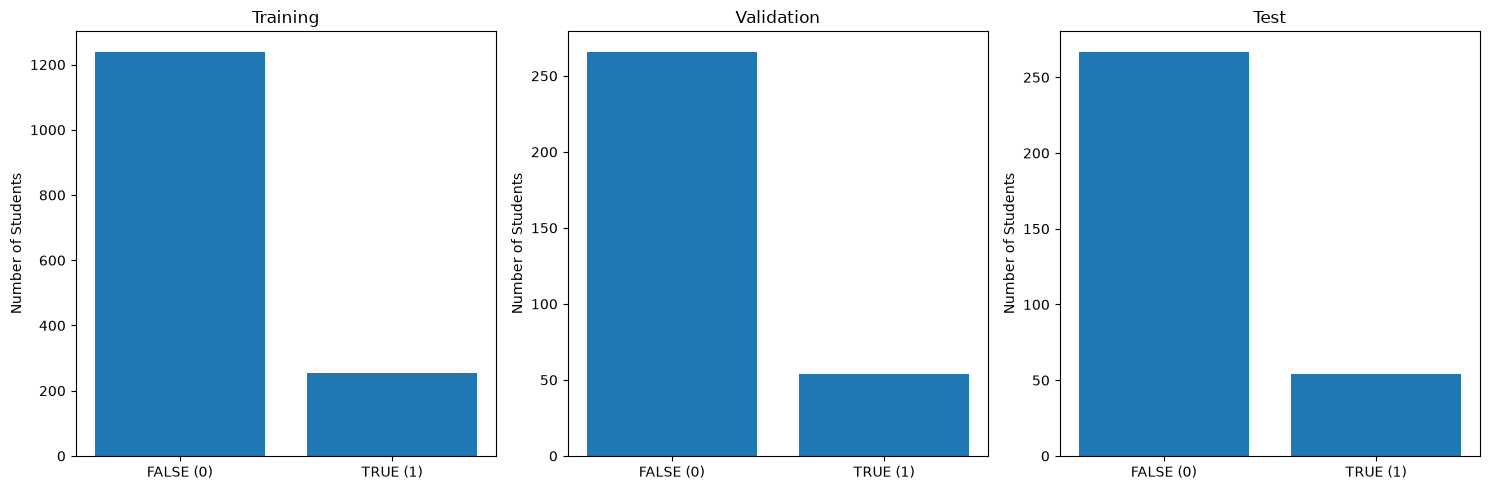

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (y_train, "Training"),
    (y_val, "Validation"),
    (y_test, "Test")
]

for ax, (target_data, title) in zip(axes, datasets):

    counts = target_data.value_counts().sort_index()

    ax.bar(
        ["FALSE (0)", "TRUE (1)"],
        [
            counts.get(0, 0),
            counts.get(1, 0)
        ]
    )

    ax.set_title(title)
    ax.set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [82]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
next_semester_dropout
0    1240
1     253
Name: count, dtype: int64

After SMOTE:
next_semester_dropout
0    1240
1    1240
Name: count, dtype: int64


In [83]:
print("VALIDATION SET")
print("Shape:", X_val.shape)
print(y_val.value_counts())

print("\nTEST SET")
print("Shape:", X_test.shape)
print(y_test.value_counts())

VALIDATION SET
Shape: (320, 4293)
next_semester_dropout
0    266
1     54
Name: count, dtype: int64

TEST SET
Shape: (321, 4293)
next_semester_dropout
0    267
1     54
Name: count, dtype: int64


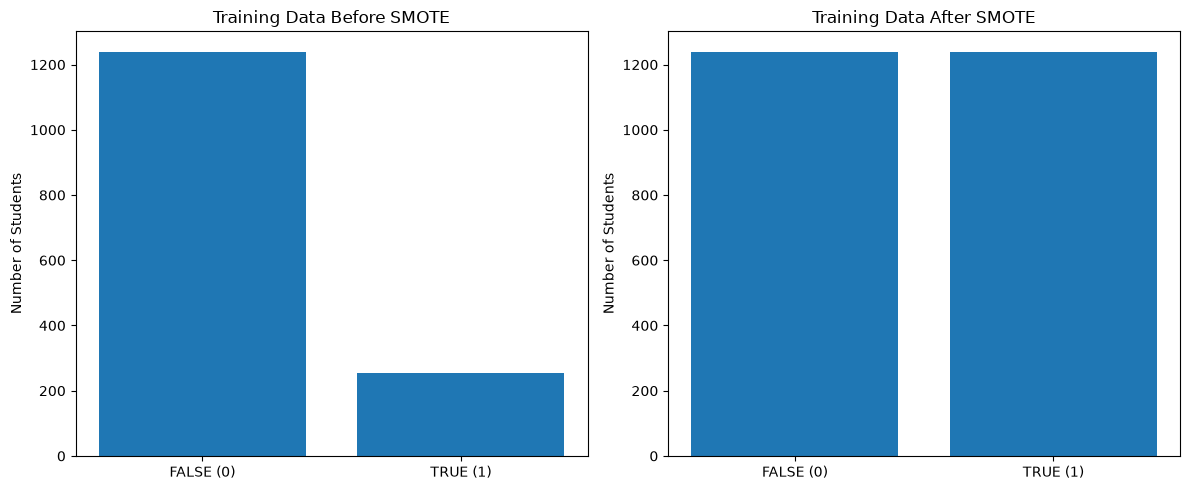

In [84]:
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
axes[0].bar(
    ["FALSE (0)", "TRUE (1)"],
    [
        before_counts.get(0, 0),
        before_counts.get(1, 0)
    ]
)

axes[0].set_title("Training Data Before SMOTE")
axes[0].set_ylabel("Number of Students")

# After SMOTE
axes[1].bar(
    ["FALSE (0)", "TRUE (1)"],
    [
        after_counts.get(0, 0),
        after_counts.get(1, 0)
    ]
)

axes[1].set_title("Training Data After SMOTE")
axes[1].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [85]:
balanced_train_df = X_train_smote.copy()

balanced_train_df[TARGET] = y_train_smote.values

print("Balanced training dataset shape:")
print(balanced_train_df.shape)

print("\nTarget distribution:")
print(balanced_train_df[TARGET].value_counts())

Balanced training dataset shape:
(2480, 4294)

Target distribution:
next_semester_dropout
0    1240
1    1240
Name: count, dtype: int64


In [86]:
balanced_train_df = balanced_train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(balanced_train_df.head())

   age  gpa_current  gpa_history  attendance_rate  enrollment_gap_months  \
0   19     2.830000     2.770000         0.770000                      0   
1   18     3.930000     3.740000         0.780000                      0   
2   23     1.630000     1.570000         0.500000                      0   
3   22     1.957782     1.717778         0.577406                      0   
4   21     2.300000     2.240000         0.810000                      3   

   credits_completed  financial_aid_status  academic_warning_count  \
0                 97                 False                       0   
1                 47                 False                       2   
2                 50                  True                       3   
3                112                 False                       0   
4                 75                  True                       3   

   advisor_meeting_count  gender_Female  ...  \
0                      4          False  ...   
1                      4  

In [87]:
print("========== FINAL BALANCED TRAINING DATA ==========")

print("\nDataset shape:")
print(balanced_train_df.shape)

print("\nTarget column:")
print(TARGET)

print("\nTarget distribution:")
print(
    balanced_train_df[TARGET].value_counts()
)

print("\nTarget percentages:")
print(
    balanced_train_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

========== FINAL BALANCED TRAINING DATA ==========

Dataset shape:
(2480, 4294)

Target column:
next_semester_dropout

Target distribution:
next_semester_dropout
1    1240
0    1240
Name: count, dtype: int64

Target percentages:
next_semester_dropout
1    50.0
0    50.0
Name: proportion, dtype: float64


In [88]:
print("========== DATA SPLIT SUMMARY ==========")

print("\nOriginal dataset:")
print(f"Rows: {len(df)}")

print("\nTraining:")
print(f"Original training rows: {len(X_train)}")
print(f"After SMOTE: {len(X_train_smote)}")
print("Target:")
print(y_train_smote.value_counts())

print("\nValidation:")
print(f"Rows: {len(X_val)}")
print("Target:")
print(y_val.value_counts())

print("\nTest:")
print(f"Rows: {len(X_test)}")
print("Target:")
print(y_test.value_counts())

========== DATA SPLIT SUMMARY ==========

Original dataset:
Rows: 2134

Training:
Original training rows: 1493
After SMOTE: 2480
Target:
next_semester_dropout
0    1240
1    1240
Name: count, dtype: int64

Validation:
Rows: 320
Target:
next_semester_dropout
0    266
1     54
Name: count, dtype: int64

Test:
Rows: 321
Target:
next_semester_dropout
0    267
1     54
Name: count, dtype: int64


========== CORRELATION WITH TARGET (SMOTE BALANCED TRAINING DATASET) ==========
next_semester_dropout     1.000000
attendance_rate           0.058654
gpa_current               0.029998
gpa_history               0.013676
advisor_meeting_count    -0.028961
credits_completed        -0.035803
age                      -0.038056
academic_warning_count   -0.093078
enrollment_gap_months    -0.166777
Name: next_semester_dropout, dtype: float64


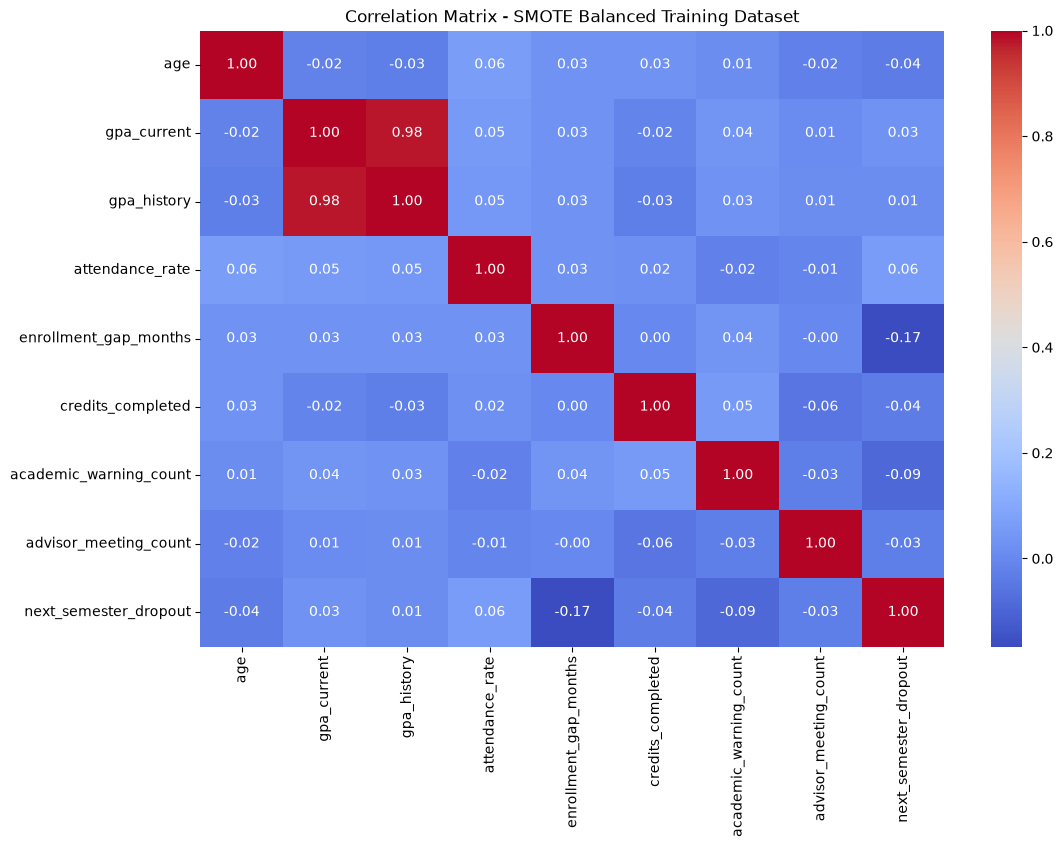

In [89]:
# ============================================================
# CORRELATION ANALYSIS - SMOTE BALANCED TRAINING DATASET
# ============================================================

# Create a copy of the SMOTE-balanced training dataset
df_corr_balanced = balanced_train_df.copy()

# Make sure the target is numeric
# FALSE = 0
# TRUE  = 1
df_corr_balanced[TARGET] = df_corr_balanced[TARGET].astype(int)

# Select numerical columns only
numeric_cols_balanced = df_corr_balanced.select_dtypes(
    include=["int64", "float64", "int32"]
).columns

# Calculate correlation of each numerical feature with the target
correlations_balanced = (
    df_corr_balanced[numeric_cols_balanced]
    .corr()[TARGET]
    .sort_values(ascending=False)
)

# Display correlation values
print("========== CORRELATION WITH TARGET (SMOTE BALANCED TRAINING DATASET) ==========")

print(correlations_balanced)

# Create correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_corr_balanced[numeric_cols_balanced].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix - SMOTE Balanced Training Dataset"
)

plt.show()

In [90]:
print("========== FIRST 5 ROWS ==========")
display(df_corr_balanced.head(5))

print("\n========== LAST 5 ROWS ==========")
display(df_corr_balanced.tail(5))

========== FIRST 5 ROWS ==========


,age,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,gender_Female,...,"attendance_by_semester_[1.0, 0.8, 0.73, 0.73]","attendance_by_semester_[1.0, 0.86, 0.98, 0.92]","attendance_by_semester_[1.0, 0.87, 0.66, 0.91]","attendance_by_semester_[1.0, 0.88, 0.87, 0.53]","attendance_by_semester_[1.0, 0.9, 0.57, 0.66]","attendance_by_semester_[1.0, 0.91, 0.85, 0.53]","attendance_by_semester_[1.0, 0.92, 0.78, 0.6]","attendance_by_semester_[1.0, 0.92, 0.95, 0.91]","attendance_by_semester_[1.0, 0.98, 0.72, 0.63]",next_semester_dropout
0,19,2.830000,2.770000,0.770000,0,97,False,0,4,False,...,False,False,False,False,False,False,False,False,False,1
1,18,3.930000,3.740000,0.780000,0,47,False,2,4,True,...,False,False,False,False,False,False,False,False,False,1
2,23,1.630000,1.570000,0.500000,0,50,True,3,3,True,...,False,False,False,False,False,False,False,False,False,0
3,22,1.957782,1.717778,0.577406,0,112,False,0,3,True,...,False,False,False,False,False,False,False,False,False,1
4,21,2.300000,2.240000,0.810000,3,75,True,3,0,True,...,False,False,False,False,False,False,False,False,False,0



========== LAST 5 ROWS ==========


,age,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,gender_Female,...,"attendance_by_semester_[1.0, 0.8, 0.73, 0.73]","attendance_by_semester_[1.0, 0.86, 0.98, 0.92]","attendance_by_semester_[1.0, 0.87, 0.66, 0.91]","attendance_by_semester_[1.0, 0.88, 0.87, 0.53]","attendance_by_semester_[1.0, 0.9, 0.57, 0.66]","attendance_by_semester_[1.0, 0.91, 0.85, 0.53]","attendance_by_semester_[1.0, 0.92, 0.78, 0.6]","attendance_by_semester_[1.0, 0.92, 0.95, 0.91]","attendance_by_semester_[1.0, 0.98, 0.72, 0.63]",next_semester_dropout
2475,20,1.586583,1.437295,0.680712,0,38,False,0,1,True,...,False,False,False,False,False,False,False,False,False,1
2476,18,2.380000,2.150000,0.570000,2,35,False,1,1,True,...,False,False,False,False,False,False,False,False,False,1
2477,23,1.880000,1.690000,0.810000,0,33,False,1,4,False,...,False,False,False,False,False,False,False,False,False,0
2478,19,2.830000,2.730000,0.640000,3,59,True,3,0,False,...,False,False,False,False,False,False,False,False,False,0
2479,18,3.450000,3.290000,0.570000,0,92,False,0,1,False,...,False,False,False,False,False,False,False,False,False,0


In [91]:
key_cols = [
    "age",
    "gpa_current",
    "gpa_history",
    "attendance_rate",
    "credits_completed",
    "academic_warning_count",
    "next_semester_dropout"
]

df_sample = (
    balanced_train_df[key_cols]
    .sample(n=30, random_state=42)
    .reset_index(drop=True)
)

display(df_sample)

,age,gpa_current,gpa_history,attendance_rate,credits_completed,academic_warning_count,next_semester_dropout
0,28,3.150000,2.900000,0.500000,51,1,0
1,20,2.710000,2.460000,0.690000,37,2,0
2,24,2.200000,1.980000,0.680000,63,1,0
3,18,3.240000,3.210000,0.910000,107,1,0
4,24,3.920000,3.700000,0.670000,108,0,0
5,27,2.289674,1.901937,0.870783,97,2,1
6,21,1.750000,1.570000,0.750000,64,3,0
7,27,2.850000,2.620000,0.970000,108,3,0
8,29,3.690000,3.270000,0.890000,67,2,0
9,27,1.530000,1.460000,0.920000,28,3,0


In [92]:
# Export SMOTE Balanced Train set, Validation set, and Test set to CSV files
import os

data_dir = "/home/chandima-bandara/Desktop/student-retention-analysis/data"

# 1. Save SMOTE Balanced Training dataset
train_smote_path = os.path.join(data_dir, "student_retention_train_smote_balanced.csv")
balanced_train_df.to_csv(train_smote_path, index=False)
print("SMOTE Balanced Train dataset exported to:", train_smote_path)
print("Shape:", balanced_train_df.shape)

# 2. Save Validation dataset
val_df = X_val.copy()
val_df[TARGET] = y_val.values
val_path = os.path.join(data_dir, "student_retention_val.csv")
val_df.to_csv(val_path, index=False)
print("\nValidation dataset exported to:", val_path)
print("Shape:", val_df.shape)

# 3. Save Test dataset
test_df = X_test.copy()
test_df[TARGET] = y_test.values
test_path = os.path.join(data_dir, "student_retention_test.csv")
test_df.to_csv(test_path, index=False)
print("\nTest dataset exported to:", test_path)
print("Shape:", test_df.shape)


SMOTE Balanced Train dataset exported to: /home/chandima-bandara/Desktop/student-retention-analysis/data/student_retention_train_smote_balanced.csv
Shape: (2480, 4294)

Validation dataset exported to: /home/chandima-bandara/Desktop/student-retention-analysis/data/student_retention_val.csv
Shape: (320, 4294)

Test dataset exported to: /home/chandima-bandara/Desktop/student-retention-analysis/data/student_retention_test.csv
Shape: (321, 4294)
